In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from util import load_and_preprocess_data, fit_maz_percentile, get_medoid_optimized, batch_cosine_dist
import matplotlib.patches as mpatches

In [6]:
def host_adaptive_distance_subtypes(segments, subtypes=['H1N1', 'H3N2', 'H1N2'], is_post2020=True):
    
    # Master list to hold data for ALL subtypes and segments
    master_data = []
    # 1. Loop through each segment first
    for seg in segments:
        dfs_to_combine = []
        print(f"Processing Segment: {seg}...")
        try:
            # Load data ONCE per segment (contains all subtypes)
            if is_post2020:
                shap_df_post2020, _, _     = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_Avian_Class_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=False)
                dfs_to_combine.append(shap_df_post2020)
                
            shap_df_pre2020, _, codon_cols = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_Avian_Class_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=False)
            dfs_to_combine.append(shap_df_pre2020)
            
            shap_df_H5Nx, _, _ = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5/H5Nx_Codon_Shap', file_pattern_shap ='H5Nx_Avian_Class_', file_pattern_rscu ='H5Nx_', verbose=False)

        except Exception as e:
            print(f"Error loading {seg}: {e}")
            continue
            
        shap_df_avian_ref = shap_df_pre2020[shap_df_pre2020['host_group'].astype(str) == 'Avian']
        if shap_df_avian_ref.empty:
            print(f"Skipping {seg}: No avian reference data.")
            continue
        
        if seg == '07_MP':
            seg = '07_M'
            
        #H5Nx North America
        X_hum_H5Nx = shap_df_H5Nx[shap_df_H5Nx['host_group']=='Human'][codon_cols].values.astype(np.float32)
        X_mam_H5Nx = shap_df_H5Nx[shap_df_H5Nx['host_group']=='Non-human Mammal'][codon_cols].values.astype(np.float32)

        # df_pre2020_01_PB2 = pd.read_csv(f'metadata/{seg}/{seg}_Train_Filtered.csv')
        # seg_id = seg[1:]+'_ID'
        # H5N1_ancestor_id = df_pre2020_01_PB2[df_pre2020_01_PB2['Isolate_Name']=='A/Goose/Guangdong/1/96'][seg_id].values[0]
        # H5N1_shap_ancestor = shap_df_pre2020[shap_df_pre2020['seq_ID']==H5N1_ancestor_id][codon_cols].values.astype(np.float32)
        # print (H5N1_ancestor_id, H5N1_shap_ancestor)
        # assert df_pre2020_01_PB2.shape[0] == shap_df_pre2020.shape[0]
        
        X_avi_H5Nx = shap_df_H5Nx[shap_df_H5Nx['host_group']=='Avian'][codon_cols].values.astype(np.float32)
        center_avi_H5Nx = get_medoid_optimized(X_avi_H5Nx)
        

        #pre2020 and post2020
        if dfs_to_combine:
            shap_df_full = pd.concat(dfs_to_combine, ignore_index=True)
        else:
            shap_df_full = pd.DataFrame()

        #Control (Aiv -> Avi)
        X_avi_pre2020_control = shap_df_avian_ref[codon_cols].values.astype(np.float32)
        center_avi_pre2020_control = get_medoid_optimized(X_avi_pre2020_control)
        
        X_avi     = shap_df_full[shap_df_full['host_group']=='Avian'][codon_cols].values.astype(np.float32)
        X_avi_all = np.concatenate((X_avi, X_avi_H5Nx), axis=0)
        d_avi_avi = batch_cosine_dist(X_avi_all, center_avi_pre2020_control)
        for val in d_avi_avi:
            master_data.append({
                'Segment': seg,
                'Subtype': r'Control (Avi$\to$Avi)',
                'Comparison': r'Hum (avi profile)$\to$Avi',
                'Distance': val
            }) 
            master_data.append({
                'Segment': seg,
                'Subtype': r'Control (Avi$\to$Avi)',
                'Comparison': r'NonHum-Mam (avi profile)$\to$Avi',
                'Distance': val
            })
            
        for subtype in subtypes:

            X_avi_pre2020_sub = shap_df_avian_ref[shap_df_avian_ref['subtype'].astype(str) == subtype][codon_cols].values.astype(np.float32)
            center_avi_pre2020_sub = get_medoid_optimized(X_avi_pre2020_sub) # The single universal anchor
            
            shap_df_sub = shap_df_full[shap_df_full['subtype'].astype(str) == subtype]
            if shap_df_sub.empty: continue
            
            groups = {g: shap_df_sub[shap_df_sub['host_group'] == g][codon_cols] 
                      for g in ['Human', 'Non-human Mammal']}
            
            # A. Human -> Avian Centroid
            if not groups['Human'].empty:
                X_hum = groups['Human'].values.astype(np.float32)
                d_hum_avi = batch_cosine_dist(X_hum, center_avi_pre2020_sub)
                
                # Add to master list
                for val in d_hum_avi:
                    master_data.append({
                        'Segment': seg,
                        'Subtype': subtype,
                        'Comparison': r'Hum (avi profile)$\to$Avi',
                        'Distance': val
                    })
                    
            if not groups['Non-human Mammal'].empty:
                X_mam = groups['Non-human Mammal'].values.astype(np.float32)
                d_mam_avi = batch_cosine_dist(X_mam, center_avi_pre2020_sub)
                
                for val in d_mam_avi:
                    master_data.append({
                        'Segment': seg,
                        'Subtype': subtype,
                        'Comparison': r'NonHum-Mam (avi profile)$\to$Avi',
                        'Distance': val
                    })
        
        d_hum_avi_H5NX = batch_cosine_dist(X_hum_H5Nx, center_avi_H5Nx)
        for val in d_hum_avi_H5NX:
            master_data.append({
                'Segment': seg,
                'Subtype': r'H5Nx (North America)', 
                'Comparison': r'Hum (avi profile)$\to$Avi',
                'Distance': val
            })
        
        d_mam_avi_H5NX = batch_cosine_dist(X_mam_H5Nx, center_avi_H5Nx)
        for val in d_mam_avi_H5NX:
            master_data.append({
                'Segment': seg,
                'Subtype': r'H5Nx (North America)',
                'Comparison': r'NonHum-Mam (avi profile)$\to$Avi',
                'Distance': val
            })
        del shap_df_full
        #gc.collect()

    import matplotlib.patches as mpatches
    
    # --- Plotting Block ---
    
    print("Generating Combined Figure...")
    df_final = pd.DataFrame(master_data)
    
    target_comparisons = [r'NonHum-Mam (avi profile)$\to$Avi', r'Hum (avi profile)$\to$Avi']
    df_plot = df_final[df_final['Comparison'].isin(target_comparisons)]
    print (df_plot.shape)
    
    # 1. Setup the FacetGrid
    g = sns.catplot(
        data=df_plot,
        x='Comparison', 
        y='Distance', 
        hue='Subtype',       
        col='Segment',       
        col_wrap=4,          
        kind='boxen',        
        height=4, 
        aspect=1.0,
        palette='Paired',    
        sharey=True,
        showfliers=False,
        legend=False,         # We will build it manually below
    )
    
    for ax in g.axes.flat:
        ax.set_ylim(0.0, 2.0)
        ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.6)
        #ax.axhline(y=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
        ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.6)
        for j, tick in enumerate(ax.xaxis.get_major_ticks()):
            tick.set_pad(2 if j % 2 == 0 else 15)
            
    g.figure.subplots_adjust(hspace=0.20, wspace=0.25)  # hspace=vertical rows, wspace=columns
    g.set_axis_labels("", "Host-adaptive Distance", fontsize=10)
    g.set_titles("{col_name}", size=12)
    
    unique_subtypes = df_plot['Subtype'].unique()
    current_palette = sns.color_palette('Paired', n_colors=len(unique_subtypes))
    
    legend_handles = [
        mpatches.Patch(color=current_palette[i], label=subtype) 
        for i, subtype in enumerate(unique_subtypes)
    ]
    
    g.fig.legend(
        handles=legend_handles,
        title="Subtype",
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08), # Anchored above the plots
        ncol=len(unique_subtypes),  # Horizontal layout
        frameon=True,
        fontsize=11
    )
    
    plt.subplots_adjust(top=0.88, hspace=0.4)
    plt.tight_layout()

    output_path = "../../results/Supplementary_Figure_S14_Host_Adaptive_Distance_Subtype_Specific_Avian.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()


Processing Segment: 01_PB2...
Processing Segment: 02_PB1...
Processing Segment: 03_PA...
Processing Segment: 04_HA...
Processing Segment: 05_NP...
Processing Segment: 06_NA...
Processing Segment: 07_MP...
Processing Segment: 08_NS...
Generating Combined Figure...
(1655942, 4)


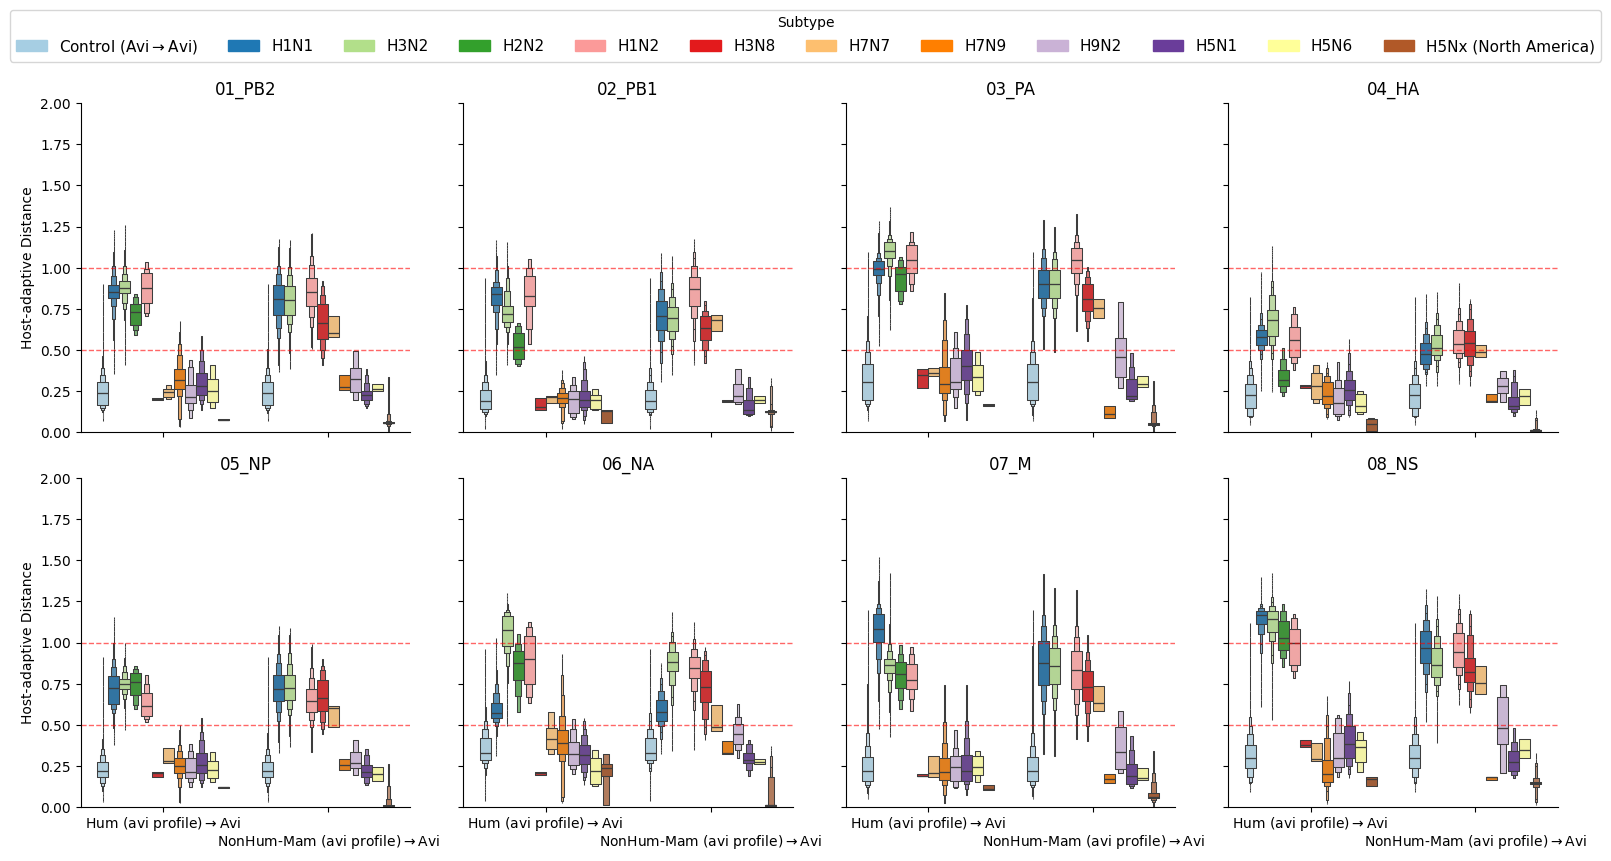

In [7]:
segments = ["01_PB2", "02_PB1", "03_PA", "04_HA", "05_NP", "06_NA", "07_MP", "08_NS"]
host_adaptive_distance_subtypes(segments, subtypes=['H1N1', 'H3N2', 'H2N2', 'H1N2', 'H3N8', 'H7N7', 'H7N9', 'H9N2', 'H5N1', 'H5N6'])